In [26]:
"""Test roughsurface interface"""
import sys
sys.path.append('../../../')
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.constants as sci_const
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook'])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from mores.interface.RoughSurface import RoughSurface
from mores.interface.HagforsSurface import HagforsSurface
from mores.utils.postprocessing import Mueller2sigma0VH, Mueller2sigma0LR, Mueller2sigma0CHV

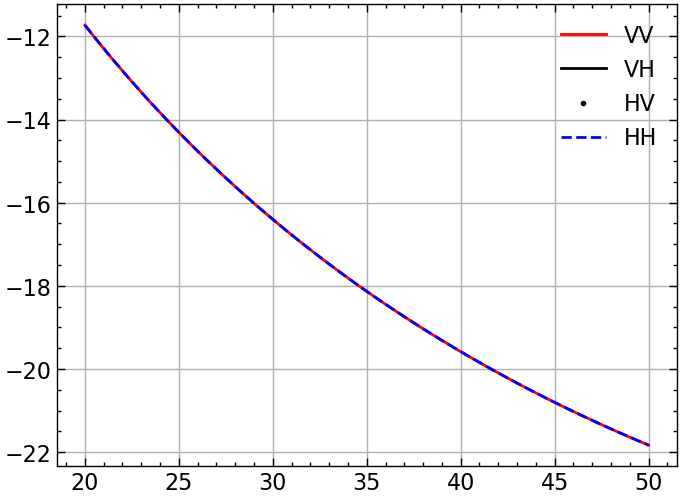

In [28]:
f = 1e9
kdel = 0.6
kcor = 3.0
epsr = 2.7 - 0.003j
c = sci_const.speed_of_light
Lambda = c / f
k = 2 * np.pi / Lambda
C_H = 100   # Hagfors roughness parameters, for only testing HagforsSurface

delta = kdel / k
corr_len = kcor / k
# rs = RoughSurface(epsilon_r=epsr, kdel=kdel, kcor=kcor, corr_fun='exp')
rs = HagforsSurface(epsilon_r=epsr, C=C_H)

theta_is = np.linspace(20, 50, 80)

N = len(theta_is)
sigma0_11 = np.zeros(N)
sigma0_12 = np.zeros(N)
sigma0_21 = np.zeros(N)
sigma0_22 = np.zeros(N)
for i in range(N):
    theta_i = theta_is[i]
    theta_s = theta_i
    geom = (theta_s, 180, theta_i, 0) 
    Mue = rs.Mue_noncoh_R(geom)
    sigma0_11[i], sigma0_12[i], sigma0_21[i], sigma0_22[i] = Mueller2sigma0VH(Mue)      # 线极化基
    # sigma0_11[i], sigma0_12[i], sigma0_21[i], sigma0_22[i] = Mueller2sigma0LR(Mue)    # 圆极化基
    # sigma0_11[i], sigma0_22[i] = Mueller2sigma0CHV(Mue)   # 圆极化发射，线极化接收
    # print(Mue)
    # exit

for sigma0 in [sigma0_11, sigma0_12, sigma0_21, sigma0_22]:
    sigma0[sigma0 <= 0] = np.nan

sigma0_11_dB = 10 * np.log10(sigma0_11)
sigma0_12_dB = 10 * np.log10(sigma0_12)
sigma0_21_dB = 10 * np.log10(sigma0_21)
sigma0_22_dB = 10 * np.log10(sigma0_22)

# show
fig, ax = plt.subplots()
ax.plot(theta_is, sigma0_11_dB, 'r', label='VV')
ax.plot(theta_is, sigma0_12_dB, 'k', label='VH')
ax.plot(theta_is, sigma0_21_dB, 'k.', label='HV')
ax.plot(theta_is, sigma0_22_dB, 'b--', label='HH')
ax.grid()
# ax.set_ylim(-40, -10)
plt.legend()
plt.show()

In [29]:
np.diag([1, 1, -1,-1])@Mue

array([[0.0005218, 0.       , 0.       , 0.       ],
       [0.       , 0.0005218, 0.       , 0.       ],
       [0.       , 0.       , 0.0005218, 0.       ],
       [0.       , 0.       , 0.       , 0.0005218]])